In [1]:
from jax import jit, random, vmap
import numpy as np
import matplotlib.pyplot as plt
import jax.numpy as jnp
from jax import config
import jax
import sys
from functools import partial

sys.path.append("../src")

jax.config.update("jax_platform_name", "cpu")

config.update("jax_enable_x64", True)

In [2]:
from configuration.rte2d_settings_ex7_oerfm import get_config
from constraints.continuous2d_oe_1_copy import (
    OddEvenDecompositionPointwiseBoundaryConstraint2D as BC,
    OddEvenDecompositionPointwiseInteriorConstraint2D as EQ,
)
from geometry.meshxd_ds import UniformMeshXYV
from modules.generator import SampleC
from modules.solution import OddEvenDecompositionConstructor2D
from solver.least_square import solve
from utils.integrate import leggauss

In [3]:
rte_config = get_config()
domain = dict(rte_config.mesh["domain"])
strides = rte_config.mesh["strides"]
kn = rte_config.model.knudsen_number
coeff_fns = rte_config.model.coeff
source_fn = rte_config.model.source
Jn = rte_config.model.Jn
num_unknowns = rte_config.model.num_unknowns["j/r"]
scale = rte_config.model.scale
activation = rte_config.model.activation
regularizer = rte_config.model.regularizer
mode = rte_config.model.sample_mode
collocation_sizes = rte_config.model.collocation_sizes
key_num = rte_config.model.random_seed
rng_key = random.key(key_num)
num_quads = rte_config.model.num_quads
mesh_j = UniformMeshXYV(domain=domain, strides=strides)
mesh_r = UniformMeshXYV(domain=domain, strides=strides)

In [4]:
rte = EQ(
    domain=domain,
    strides=strides,
    Jn=Jn,
    scale=scale,
    init_rng=rng_key,
    num_quads=num_quads,
    kn=kn,
    activation=activation,
    coeff_fns=coeff_fns,
)
bc = BC(
    domain=domain,
    strides=strides,
    Jn=Jn,
    scale=scale,
    init_rng=rng_key,
    kn=kn,
    activation=activation,
)

In [5]:
dummy_x, dummy_y, dummy_theta = jnp.split(
    jnp.array([0.1, 0.5, 0.2]), 3, axis=0)
params = {}
# eq_instance = rte.apply(params, dummy_x, dummy_y, dummy_theta)
# bc_instance = bc.apply(params, dummy_x, dummy_y, dummy_theta)

In [6]:
# eq_instance.shape, bc_instance.shape

In [7]:
def eq_fn(x, y, theta):
    return partial(rte.apply, params)(x, y, theta)


def bc_fn(x, y, theta):
    return partial(bc.apply, params)(x, y, theta)


def rhs_fn(x, y, theta):
    quadratures = leggauss(num_quads, (0, jnp.pi))
    pts, ws = quadratures

    def q_sym1(x, y, theta):
        return 0.5 * (source_fn(x, y, theta) + source_fn(x, y, -theta))

    def q_asym1(x, y, theta):
        return 0.5 * (source_fn(x, y, theta) - source_fn(x, y, -theta))

    # 角度积分，算平均源项
    weighted_sum1 = vmap(q_sym1, [None, None, 0])(x, y, pts) * ws
    avg_q1 = jnp.sum(weighted_sum1) / (jnp.pi)

    rhs = jnp.stack(
        [
            avg_q1.squeeze(),
            kn**2 * (q_sym1(x, y, theta) - avg_q1).squeeze(),
            kn * q_asym1(x, y, theta).squeeze(),
        ],
        axis=0,
    )
    return rhs


vmap_eq_fn, vmap_bc_fn, vmap_rhs_fn = (
    jit(vmap(eq_fn)),
    jit(vmap(bc_fn)),
    jit(vmap(rhs_fn)),
)

In [8]:
sampler = SampleC(
    domain=domain, collocation_sizes=collocation_sizes, mode=mode)
pts_int, pts_left, pts_right, pts_lower, pts_upper = (
    sampler.pts_int,
    sampler.pts_left,
    sampler.pts_right,
    sampler.pts_lower,
    sampler.pts_upper,
)

In [9]:
# Evaluate the functions
bc_left, bc_right, bc_lower, bc_upper = (
    vmap_bc_fn(*pts_left),
    vmap_bc_fn(*pts_right),
    vmap_bc_fn(*pts_lower),
    vmap_bc_fn(*pts_upper),
)
print(
    f"bc_left.shape: {bc_left.shape}, bc_right.shape: {bc_right.shape}, bc_lower.shape: {bc_lower.shape}, bc_upper.shape: {bc_upper.shape}"
)

bc_left.shape: (8192, 256), bc_right.shape: (8192, 256), bc_lower.shape: (8192, 256), bc_upper.shape: (8192, 256)


In [10]:
eq_int = vmap_eq_fn(*pts_int)
print(f"eq_int.shape: {eq_int.shape}")  # ((Nx-2) * (Ny-2) * (Ntheta-2),3,32)

eq_int.shape: (98304, 3, 256)


In [11]:
x_int, y_int, theta_int = pts_int
pts_int = x_int.squeeze(), y_int.squeeze(), theta_int.squeeze()
rhs_int = vmap_rhs_fn(*pts_int)
print(f"rhs_int.shape: {rhs_int.shape}")

rhs_int.shape: (98304, 3)


In [12]:
def ex_solution_2d(x: jnp.ndarray, y: jnp.ndarray, theta: jnp.ndarray) -> jnp.ndarray:
    return jnp.exp(-x) * jnp.exp(-y)


vmap_ex_fn = vmap(jit(ex_solution_2d))

In [13]:
# Save the data
matrix_A = np.concatenate(
    [
        bc_left,
        bc_right,
        bc_lower,
        bc_upper,
        eq_int.reshape(-1, num_unknowns),
    ],
    axis=0,
)

vector_b = np.zeros((matrix_A.shape[0], 1))
bdy_size_x, bdy_size_y, bdy_size_theta = collocation_sizes["boundary"]
vector_b[: 2 * bdy_size_y * bdy_size_theta,
         0] = vmap_ex_fn(*pts_left).squeeze()
vector_b[
    2 * bdy_size_y * bdy_size_theta: 4 * bdy_size_y * bdy_size_theta,
    0,
] = vmap_ex_fn(*pts_right).squeeze()
vector_b[
    4 * bdy_size_y * bdy_size_theta: 4 * bdy_size_y * bdy_size_theta
    + 2 * bdy_size_x * bdy_size_theta,
    0,
] = vmap_ex_fn(*pts_lower).squeeze()
vector_b[
    4 * bdy_size_y * bdy_size_theta + 2 * bdy_size_x * bdy_size_theta: 4
    * bdy_size_y
    * bdy_size_theta
    + 4 * bdy_size_x * bdy_size_theta,
    0,
] = vmap_ex_fn(*pts_upper).squeeze()

vector_b[
    4 * bdy_size_y * bdy_size_theta + 4 * bdy_size_x * bdy_size_theta:, 0] = (
    rhs_int.reshape(-1)
)


print(f"Matrix A: {matrix_A.shape}, Vector b: {vector_b.shape}")

Matrix A: (327680, 256), Vector b: (327680, 1)


In [14]:
print("Matrix A 内存 %.2f MB" % (matrix_A.nbytes / 1024**2))
print("Vector b 内存 %.2f MB" % (vector_b.nbytes / 1024**2))

num_zero = np.sum(matrix_A == 0).item()
total = matrix_A.size
sparsity = num_zero / total
print(f"A的稀疏度 = {sparsity:.2%} (零元素比例)")
num_zero = np.sum(vector_b == 0).item()
total = vector_b.size
sparsity = num_zero / total
print(f"b的稀疏度 = {sparsity:.2%} (零元素比例)")

Matrix A 内存 640.00 MB
Vector b 内存 2.50 MB
A的稀疏度 = 1.33% (零元素比例)
b的稀疏度 = 0.00% (零元素比例)


In [16]:
vector_U = solve(matrix_A, vector_b, c=regularizer)
print(f"Vector U: {vector_U.shape}")

Vector U: (256, 1)


In [17]:
error = matrix_A @ vector_U - vector_b
(
    np.abs(error).max(),
    np.abs(error).mean(),
)

(69.56843901293658, 0.3997835901010133)

In [18]:
coefficients = jnp.array(vector_U).reshape(
    num_unknowns,
)
constructor = OddEvenDecompositionConstructor2D(
    domain=domain,
    strides=strides,
    Jn=Jn,
    scale=scale,
    init_rng=rng_key,
    kn=kn,
    activation=activation,
    coefficients=coefficients,
)

In [19]:
def approx_fn(x, y, theta):
    return partial(constructor.apply, params)(x, y, theta)

In [20]:
def rho(x, y):
    return jnp.exp(-x) * jnp.exp(-y)

In [21]:
def aver_fn(x, y):
    quadratures = leggauss(num_quads, (-jnp.pi, jnp.pi))
    pts, ws = quadratures
    weighted_sum = vmap(approx_fn, [None, None, 0])(x, y, pts) @ ws
    return weighted_sum / jnp.pi / 2.0

In [22]:
# vmap_approx_fn = vmap(approx_fn)
approx_fn = jit(approx_fn)

In [23]:
dummy_z = jnp.array([0, 0, 0])
dummy_x, dummy_y, dummy_v = jnp.split(dummy_z, 3, axis=-1)
print(
    f"f({dummy_z}) = {approx_fn(dummy_x, dummy_y, dummy_v)}"
)  # f([0. 0. 0.]) = 1.000002714641632

f([0 0 0]) = 0.6671150727815984


In [24]:
def mask_C(X, Y):
    in_top = (Y >= 2.0) & (Y <= 3.0) & (X >= -3.0) & (X <= 3.0)
    in_bot = (Y >= -3.0) & (Y <= -2.0) & (X >= -3.0) & (X <= 3.0)
    in_left = (X >= -3.0) & (X <= -2.0) & (Y >= -2.0) & (Y <= 2.0)
    return in_top | in_bot | in_left


def mask_C_curve(X, Y):
    """
    C-shaped domain mask:
    - Left half-circle (半圆环)
    - Top and bottom horizontal rectangles
    """
    # -----------------------------
    # Left half-circle
    # -----------------------------
    R_outer = 3.0
    R_inner = 2.0
    radius = np.sqrt((X-1)**2 + Y**2)
    left_circle = (X <= 1) & (radius <= R_outer) & (radius >= R_inner)

    # -----------------------------
    # Top and bottom rectangles
    # -----------------------------
    top_rect = (Y >= 2.0) & (Y <= 3.0) & (X >= 1.0) & (X <= 2.0)
    bottom_rect = (Y >= -3.0) & (Y <= -2.0) & (X >= 1.0) & (X <= 2.0)

    # -----------------------------
    # Combine
    # -----------------------------
    return left_circle | top_rect | bottom_rect

In [25]:
mesh_x = np.linspace(-2.0, 2.0, 129)
mesh_y = np.linspace(-3.0, 3.0, 129)

X, Y = np.meshgrid(mesh_x, mesh_y)

rho_approx = vmap(aver_fn, [0, 0])(
    X.reshape(-1, 1),
    Y.reshape(-1, 1),
).reshape(X.shape)

rho_ex = vmap(rho, [0, 0])(X, Y)
shape_matrix = mask_C_curve(X, Y)
shape_matrix = shape_matrix.astype(float)
shape_matrix[~mask_C_curve(X, Y)] = None

F = rho_ex * shape_matrix
F_hat = rho_approx * shape_matrix
F.shape, F_hat.shape

((129, 129), (129, 129))

In [26]:
# np.savez(
#     f"../src/data/OERFM2d_ex6_solutions_{kn:.1e}.npz",
#     X=X,
#     Y=Y,
#     rho_hat=rho_approx * shape_matrix,
#     rho_ex=rho_ex * shape_matrix,
# )

# print(kn)

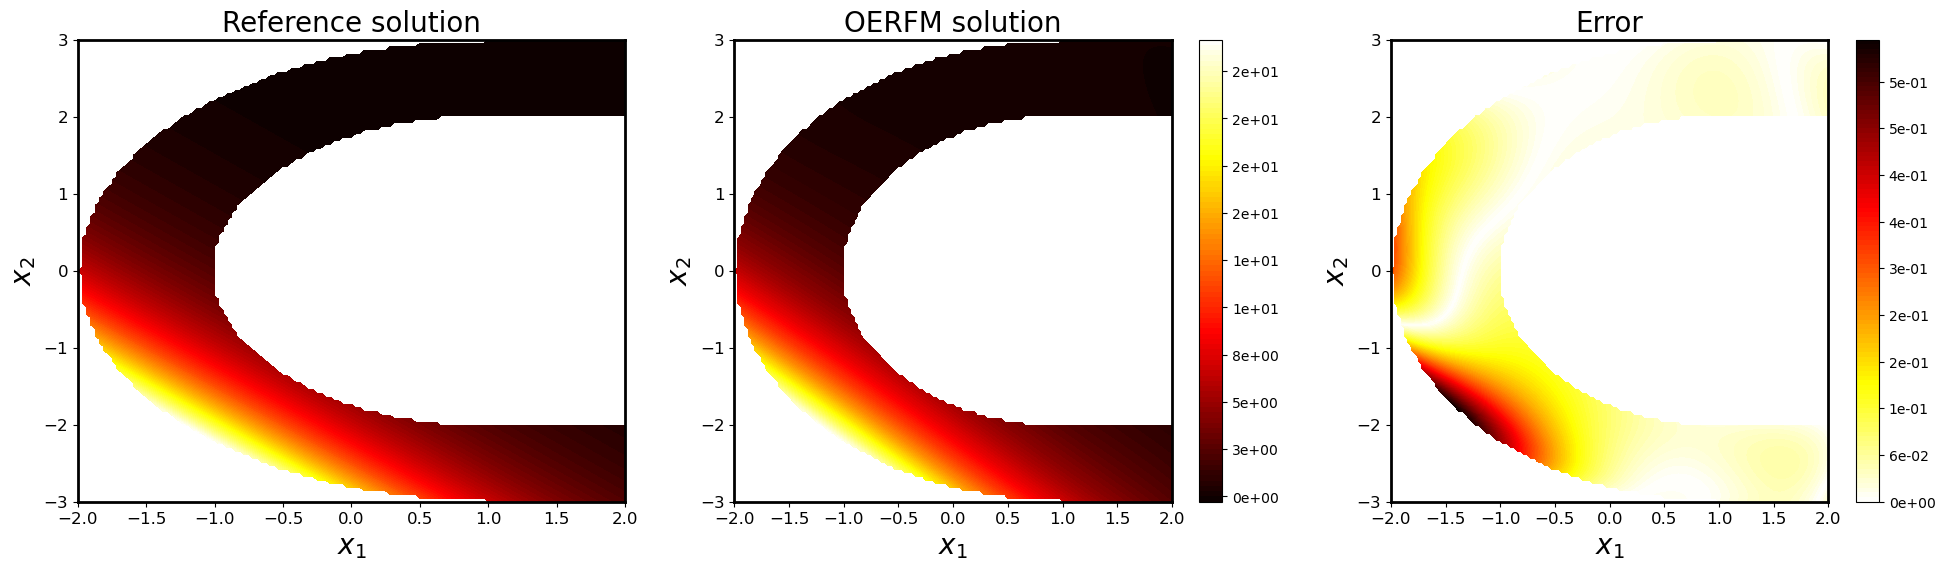

In [27]:
font_format = {"size": 20}

plt.figure(figsize=(24, 6))
ax1 = plt.subplot(1, 3, 1)
plt.contourf(X, Y, F, 100, cmap="hot")
# font size and type
plt.xticks(size=12)
plt.yticks(size=12)
plt.xlabel(r"$x_1$", font_format)
plt.ylabel(r"$x_2$", font_format)
plt.title("Reference solution", font_format)
# # line width of four axises
ax1.spines["bottom"].set_linewidth(2)
ax1.spines["left"].set_linewidth(2)
ax1.spines["right"].set_linewidth(2)
ax1.spines["top"].set_linewidth(2)

ax2 = plt.subplot(1, 3, 2)
plt.contourf(X, Y, F_hat, 100, cmap="hot")
plt.xticks(size=12)
plt.yticks(size=12)
plt.xlabel(r"$x_1$", font_format)
plt.ylabel(r"$x_2$", font_format)
plt.colorbar(format="%.0e")
plt.title("OERFM solution", font_format)
# # line width of four axises
ax2.spines["bottom"].set_linewidth(2)
ax2.spines["left"].set_linewidth(2)
ax2.spines["right"].set_linewidth(2)
ax2.spines["top"].set_linewidth(2)

ax3 = plt.subplot(1, 3, 3)
plt.contourf(X, Y, np.abs(F - F_hat), 100, cmap="hot_r")
# plt.contourf(X, V, np.abs(F - F_hat), 100, cmap='Spectral_r')
plt.xticks(size=12)
plt.yticks(size=12)
plt.xlabel(r"$x_1$", font_format)
plt.ylabel(r"$x_2$", font_format)
plt.colorbar(format="%.0e")
plt.title("Error", font_format)
# # line width of four axises
ax3.spines["bottom"].set_linewidth(2)
ax3.spines["left"].set_linewidth(2)
ax3.spines["right"].set_linewidth(2)
ax3.spines["top"].set_linewidth(2)
# plt.savefig(f"./figures/OERFM2d_{kn:.1e}_contourf_ex4.png", dpi=300)
plt.show()
plt.close()

In [28]:
mask = ~np.isnan(F)
err = np.linalg.norm((F_hat - F)[mask]) / np.linalg.norm(F[mask])
err

0.017134975848006825

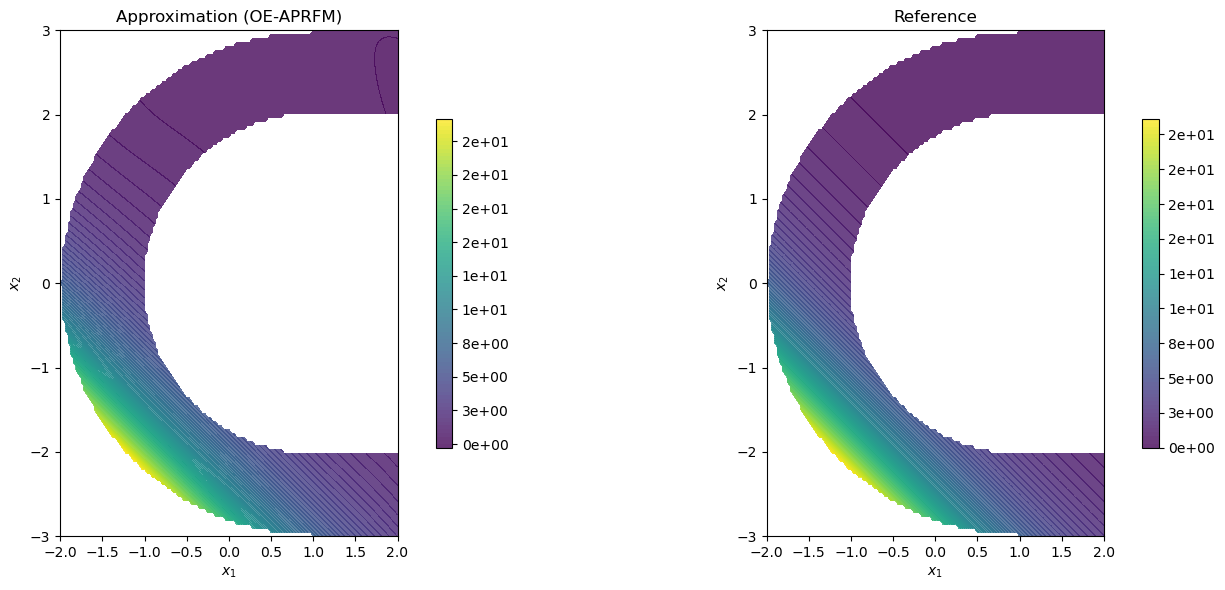

In [29]:
# 2D 等高线投影图（contour plot 风格）
import matplotlib.pyplot as plt
import numpy as np

fig = plt.figure(figsize=(15, 6))

# ------------------ Approximation ------------------
ax1 = fig.add_subplot(121)
contour1 = ax1.contourf(X, Y, F_hat, levels=100, alpha=0.8, cmap="viridis")
ax1.set_xlabel(r"$x_1$")
ax1.set_ylabel(r"$x_2$")
ax1.set_title(r"Approximation (OE-APRFM)")
ax1.set_aspect("equal")
cbar1 = plt.colorbar(contour1, ax=ax1, shrink=0.65, aspect=20, format="%.0e")

# ------------------ Reference ------------------
ax2 = fig.add_subplot(122)
contour2 = ax2.contourf(X, Y, F, levels=100, alpha=0.8, cmap="viridis")
ax2.set_xlabel(r"$x_1$")
ax2.set_ylabel(r"$x_2$")
ax2.set_title(r"Reference")
ax2.set_aspect("equal")
cbar2 = plt.colorbar(contour2, ax=ax2, shrink=0.65, aspect=20, format="%.0e")

plt.tight_layout()
# plt.savefig(f"./rte2d_rho_contour_{kn:.1e}.png", dpi=300)
plt.show()
plt.close()